# DATASCI 506 Notes

# 9.15

# Scope

In [1]:
x <- 2
printer <- function() {
  print(paste("First value of x is:", x))
  x <- 5
  print(paste("Second value of x is:", x))
}
printer()

[1] "First value of x is: 2"
[1] "Second value of x is: 5"


In [2]:
x <- 2
printer <- function() {
  print(paste("First value of x is:", x))
  x <<- 500
  print(paste("Second value of x is:", x)) #double arrow operator will change the value of x in the global environment
}
printer()
x

[1] "First value of x is: 2"
[1] "Second value of x is: 500"


[1] 500

# Conditionals

In [3]:
if (2+2==5){
    print("This is true")
} else {
    print("This is false")
}

[1] "This is false"


# Control Statements

## For loop

In [4]:
for (i in 1:10){
    print(i)
}

[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9
[1] 10


## While loop

In [5]:
n <- 1
while (n < 10){
    print(n)
    n <- n + 1
}

[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9


In [6]:
n <- 1
while (n < 10){
    print(n)
    n <- n + 1
    break
}

[1] 1


In [7]:
n <- 1
while (n<5){
    n <- n + 1
    if (n == 3) {
        next
    }
    print(n)
}

[1] 2
[1] 4
[1] 5


## Vectorization

In [8]:
x <- 0:50000000
mysum <- 0
for (i in 1:length(x)){
    mysum <- mysum + x[i]
}
mysum
system.time({
    mysum <- 0
    for (i in 1:length(x)){
        mysum <- mysum + x[i]
    }
})
system.time(sum(x))

[1] 1.25e+15

   user  system elapsed 
  0.673   0.006   0.685 

   user  system elapsed 
      0       0       0 

## The apply family of functions

In [9]:
my_matrix <- matrix(1:9, nrow = 3, byrow = TRUE)
print(my_matrix)



     [,1] [,2] [,3]
[1,]    1    2    3
[2,]    4    5    6
[3,]    7    8    9


In [10]:
row_totals <- apply(my_matrix, 1, sum) #1 indicates rows, 2 indicates columns
print(row_totals)

[1]  6 15 24


In [11]:
col_averages <- apply(my_matrix, 2, mean)
print(col_averages)


[1] 4 5 6


In [12]:
my_matrix[3] 

[1] 7

## lapply(),sapply(),vapply() works on data frame

In [13]:
data(mtcars)
sapply(mtcars,mean)
lapply(mtcars,mean)
vapply(mtcars,mean,1) #vapply is similar to sapply but it requires you to specify the type of output you want. In this case, we want a numeric output, so we specify 1.

mpg        cyl       disp         hp       drat         wt       qsec 
 20.090625   6.187500 230.721875 146.687500   3.596563   3.217250  17.848750 
        vs         am       gear       carb 
  0.437500   0.406250   3.687500   2.812500

$mpg
[1] 20.09062

$cyl
[1] 6.1875

$disp
[1] 230.7219

$hp
[1] 146.6875

$drat
[1] 3.596563

$wt
[1] 3.21725

$qsec
[1] 17.84875

$vs
[1] 0.4375

$am
[1] 0.40625

$gear
[1] 3.6875

$carb
[1] 2.8125

mpg        cyl       disp         hp       drat         wt       qsec 
 20.090625   6.187500 230.721875 146.687500   3.596563   3.217250  17.848750 
        vs         am       gear       carb 
  0.437500   0.406250   3.687500   2.812500

In [14]:
tapply(mtcars$mpg, mtcars$cyl, mean) #tapply applies a function to a vector (in this case, mpg) grouped by a factor (in this case, cyl)
#group by the number of cylinders and calculate the mean mpg for each group

4        6        8 
26.66364 19.74286 15.10000

## More On Vectorization


### Given a number, it returns the negative value 

In [15]:
negabs <- function(x) {
  if (x < 0) {
    return(abs(x))
  } else {
    return(-x)
  }
}

### But it can't take in a vector

In [16]:
## negabs(c(5,2,-1))

In [17]:
output <- c()
for (x in c(5,2,-1)){
  output <- c(output, negabs(x))
}
output

[1] -5 -2  1

# 9.17

## Random Seeds

In [18]:
set.seed(42)
a = runif(1)

set.seed(42)
b = runif(1)

a == b

[1] TRUE

## Estimate $\pi$

In [19]:
library(plotrix)

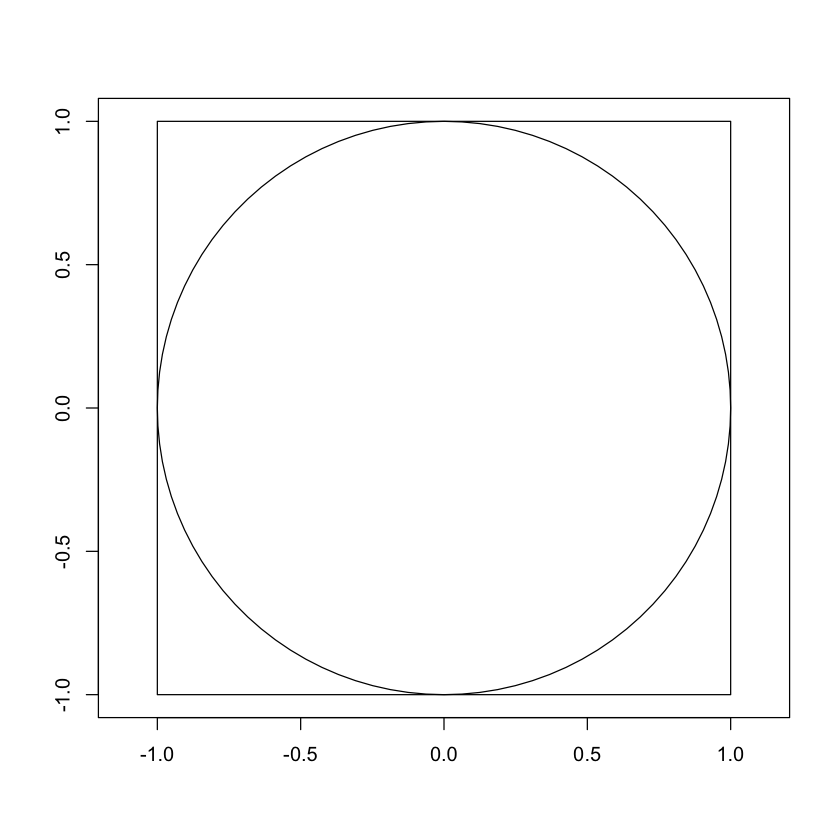

In [20]:
plot(NULL, xlim = c(-1,1), ylim = c(-1,1), asp = 1, xlab = "",
     ylab = "")
rect(-1, -1, 1, 1)
plotrix::draw.circle(0, 0, 1)

In [21]:
#' Estimates the value of pi by the proportion of points inside a square falling
#' inside a circle inscribed in that square.
#' @param n number of iterations
#' @return estimate of pi
estimate_pi <- function(n) {
  xcoord <- runif(n, -1, 1)
  ycoord <- runif(n, -1, 1)
  in_circle <- sqrt(xcoord^2 + ycoord^2) <= 1
  return(4 * sum(in_circle)/n) # estimate of pi
}

In [22]:
estimate_pi(100000000)

[1] 3.141498

## Cauculate CI

In [ ]:
mcrep <- 10000                  # Simulation replications
n <- 30                         # Sample size we are studying
sim <- rexp(n * mcrep,          # Simulate standard exponential data
            rate = 1)           # mean = 1/rate 
xmat <- matrix(sim,             # Reshape to matrix
               ncol = mcrep)
mn <- apply(xmat, 2, mean)      # Sample mean of each column (replicate)
std <- apply(xmat, 2, sd)       # Sample SD of each column (replicate)
se <- std / sqrt(n)             # Standard errors of the mean
m <- qt(1 - (1 - .95) / 2,
        df = n - 1)             # Multiplier for confidence level
lcb <- mn - m * se              # lower confidence bounds
ucb <- mn + m * se              # upper confidence bounds

In [26]:
cvrg <- sum(lcb < 1 & ucb > 1)/mcrep
cvrg

[1] 0.9253